# **Run if you have a GPU**

In [ ]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"✅ Success! GPU is available: {gpus}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("❌ GPU not detected. Go to Runtime > Change runtime type and select T4 GPU.")


✅ Success! GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **Importing the libraries**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# **Importing and Reading the Dataset**

In [ ]:
import kagglehub
path = kagglehub.dataset_download("adityajn105/flickr8k")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flickr8k' dataset.
Path to dataset files: /kaggle/input/flickr8k


In [ ]:
df=pd.read_csv(path+"/captions.txt")
df

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
...,...,...
40450,997722733_0cb5439472.jpg,A man in a pink shirt climbs a rock face
40451,997722733_0cb5439472.jpg,A man is rock climbing high in the air .
40452,997722733_0cb5439472.jpg,A person in a red shirt climbing up a rock fac...
40453,997722733_0cb5439472.jpg,A rock climber in a red shirt .


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.image import load_img, img_to_array
img_path = (path+"/Images")

In [ ]:
def readimage(path,img_size=224):
    img = load_img(path,color_mode='rgb',target_size=(img_size,img_size))
    img = img_to_array(img)
    img = img/255.
    return img

def display_image(path,img):
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    caption=df[df['image']==path]['caption'].values
    print(caption)


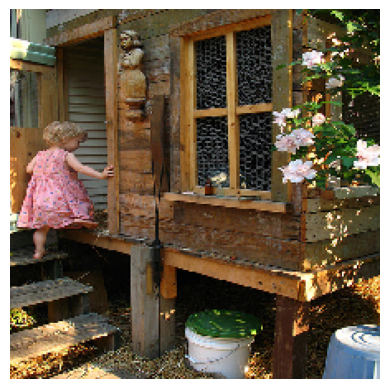

['A child in a pink dress is climbing up a set of stairs in an entry way .'
 'A girl going into a wooden building .'
 'A little girl climbing into a wooden playhouse .'
 'A little girl climbing the stairs to her playhouse .'
 'A little girl in a pink dress going into a wooden cabin .']


In [ ]:
display_image('1000268201_693b08cb0e.jpg',readimage(img_path+'/1000268201_693b08cb0e.jpg'))

# **Tokenizing the description**

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [ ]:
def preprocess(df):
    df['caption'] = df['caption'].str.lower()
    df['caption'] = df['caption'].str.replace("[^a-z\s]", "", regex=True)
    df['caption'] = df['caption'].str.replace(r"\s+", " ", regex=True)
    df['caption'] = df['caption'].apply(lambda x: " ".join([word for word in x.split() if len(word) > 1]))
    df['caption'] = "startseq " + df['caption'] + " endseq"
    return df

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4247/1323237686.py:3: SyntaxWarning: invalid escape sequence '\s'
  df['caption'] = df['caption'].str.replace("[^a-z\s]", "", regex=True)


In [ ]:
df=preprocess(df)
df

,image,caption
0,1000268201_693b08cb0e.jpg,startseq child in pink dress is climbing up se...
1,1000268201_693b08cb0e.jpg,startseq girl going into wooden building endseq
2,1000268201_693b08cb0e.jpg,startseq little girl climbing into wooden play...
3,1000268201_693b08cb0e.jpg,startseq little girl climbing the stairs to he...
4,1000268201_693b08cb0e.jpg,startseq little girl in pink dress going into ...
...,...,...
40450,997722733_0cb5439472.jpg,startseq man in pink shirt climbs rock face en...
40451,997722733_0cb5439472.jpg,startseq man is rock climbing high in the air ...
40452,997722733_0cb5439472.jpg,startseq person in red shirt climbing up rock ...
40453,997722733_0cb5439472.jpg,startseq rock climber in red shirt endseq


In [ ]:
describe=df['caption'].tolist()
describe[:11]

['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
 'startseq girl going into wooden building endseq',
 'startseq little girl climbing into wooden playhouse endseq',
 'startseq little girl climbing the stairs to her playhouse endseq',
 'startseq little girl in pink dress going into wooden cabin endseq',
 'startseq black dog and spotted dog are fighting endseq',
 'startseq black dog and tricolored dog playing with each other on the road endseq',
 'startseq black dog and white dog with brown spots are staring at each other in the street endseq',
 'startseq two dogs of different breeds looking at each other on the road endseq',
 'startseq two dogs on pavement moving toward each other endseq',
 'startseq little girl covered in paint sits in front of painted rainbow with her hands in bowl endseq']

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(describe)

In [ ]:
images=df['image'].unique().tolist()
images[:11]

['1000268201_693b08cb0e.jpg',
 '1001773457_577c3a7d70.jpg',
 '1002674143_1b742ab4b8.jpg',
 '1003163366_44323f5815.jpg',
 '1007129816_e794419615.jpg',
 '1007320043_627395c3d8.jpg',
 '1009434119_febe49276a.jpg',
 '1012212859_01547e3f17.jpg',
 '1015118661_980735411b.jpg',
 '1015584366_dfcec3c85a.jpg',
 '101654506_8eb26cfb60.jpg']

# **Training And Building The Model**

In [ ]:
from sklearn.model_selection import train_test_split
x=images
y=[describe[i:i+5] for i in range(0, len(describe), 5)]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x_train_flat = [img for img in x_train for _ in range(5)]
y_train_flat = [caption for sublist in y_train for caption in sublist]
len(x_train),len(x_test),len(y_train),len(y_test),len(x_train_flat),len(y_train_flat)

(6472, 1619, 6472, 1619, 32360, 32360)

In [ ]:
from tensorflow.keras import layers, models
BATCH_SIZE = 256
VOCAB_SIZE = 10000
MAX_LENGTH = 32
IMAGE_SIZE = (224, 224)

def load_and_preprocess_image(img_name):
    img_file = tf.strings.join([img_path, "/", img_name])
    img_raw = tf.io.read_file(img_file)
    img_tensor = tf.image.decode_jpeg(img_raw, channels=3)
    img_tensor = tf.image.resize(img_tensor, IMAGE_SIZE)
    img_tensor = img_tensor / 255.0
    return img_tensor

vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_LENGTH
)
vectorizer.adapt(y_train_flat)

def map_dataset(image_name, describe_text):
    img_tensor = load_and_preprocess_image(image_name)
    vectorized_describe = vectorizer(describe_text)
    text_input = vectorized_describe[:-1]
    text_target = vectorized_describe[1:]
    return {
        "image_input_layer": img_tensor,
        "text_input_layer": text_input
    }, text_target

train_dataset_mapped = tf.data.Dataset.from_tensor_slices((x_train_flat, y_train_flat))
train_dataset_mapped = train_dataset_mapped.map(map_dataset, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset_mapped = train_dataset_mapped.shuffle(buffer_size=1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

image_input = layers.Input(shape=(224, 224, 3), name="image_input_layer")
x1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(image_input)
x1 = layers.MaxPooling2D((2, 2))(x1)
x1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x1)
x1 = layers.MaxPooling2D((2, 2))(x1)
x1 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x1)
x1 = layers.MaxPooling2D((2, 2))(x1)
x1 = layers.Flatten()(x1)
image_features = layers.Dense(256, activation='relu')(x1)

text_input_layer = layers.Input(shape=(MAX_LENGTH - 1,), name="text_input_layer")
x2 = layers.Embedding(input_dim=VOCAB_SIZE, output_dim=256, mask_zero=True)(text_input_layer)
text_features = layers.LSTM(256, return_sequences=True)(x2)

image_features_seq = layers.RepeatVector(MAX_LENGTH - 1)(image_features)
merged_features = layers.add([image_features_seq, text_features])
decoder_dense = layers.TimeDistributed(layers.Dense(256, activation='relu'))(merged_features)
model_outputs = layers.TimeDistributed(layers.Dense(VOCAB_SIZE, activation='softmax'), name="final_word_predictor")(decoder_dense)
model = models.Model(inputs=[image_input, text_input_layer], outputs=model_outputs)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

model.fit(
    train_dataset_mapped,
    epochs=20,
    verbose=1
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input_layer   │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ image_input_laye… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 100352)    │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input_layer    │ (None, 31)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │ 25,690,368 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 31, 256)   │  2,560,000 │ text_input_layer… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 31)        │          0 │ text_input_layer… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 31, 256)   │          0 │ dense[0][0]       │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 31, 256)   │    525,312 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 31, 256)   │          0 │ repeat_vector[0]… │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 31, 256)   │     65,792 │ add[0][0]         │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_word_predict… │ (None, 31, 10000) │  2,570,000 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 31,504,720 (120.18 MB)

 Trainable params: 31,504,720 (120.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 137s 923ms/step - accuracy: 0.6786 - loss: 2.9671
Epoch 2/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 118s 824ms/step - accuracy: 0.7238 - loss: 1.6924
Epoch 3/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 145s 848ms/step - accuracy: 0.7383 - loss: 1.5112
Epoch 4/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 122s 937ms/step - accuracy: 0.7470 - loss: 1.4169
Epoch 5/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 114s 877ms/step - accuracy: 0.7538 - loss: 1.3400
Epoch 6/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 111s 851ms/step - accuracy: 0.7591 - loss: 1.2748
Epoch 7/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 144s 865ms/step - accuracy: 0.7640 - loss: 1.2165
Epoch 8/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 110s 839ms/step - accuracy: 0.7696 - loss: 1.1576
Epoch 9/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 141s 834ms/step - accuracy: 0.7757 - loss: 1.0973
Epoch 10/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 108s 825ms/step - accuracy: 0.7824 - loss: 1.0358
Epoch 11/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 108s 823ms/step - accuracy: 0.7895 - loss: 0.9737
Epoch 12

In [ ]:
model.save("image_description_model.keras")

import pickle
with open("vocab.pkl", "wb") as f:
    pickle.dump(vectorizer.get_vocabulary(), f)
